# Districting report

Reads the partition store that `kedro run --pipeline districting` wrote for the network
selected in `conf/base/globals.yml`, and keeps the POC's reporting sections: **§4** the dials,
live; **§5** method comparison; **§6** sanity checks; **§7** summary.

Nothing here writes. The partitions under `data/01_raw/<network>/partitions/<method>/` and the
tables under `data/08_reporting/districting/<network>/` are produced by the pipeline; the
widgets below re-run the same node in memory, and §1 checks that what is drawn is what is
on disk.

In [1]:
%matplotlib inline
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from kedro.framework.session import KedroSession
from kedro.framework.startup import bootstrap_project

HERE = Path.cwd()
ROOT = next(p for p in [HERE, *HERE.parents] if (p / "conf" / "base").exists())
bootstrap_project(ROOT)
session = KedroSession.create(project_path=ROOT)
context = session.load_context()
catalog, params = context.catalog, context.params

from fedwater import districting as dst
from fedwater.networks import partitions as pstore
from fedwater.pipelines.districting.nodes import build_partitions

warnings.simplefilter("ignore")
pd.set_option("display.width", 240, "display.max_columns", 80)
plt.rcParams.update({"figure.dpi": 110, "font.size": 8})

wn = catalog.load("network_inp")
profile = catalog.load("network_profile")
manual = catalog.load("districts_manual")
DP = params["districting"]
NETWORK = profile["name"]
K = pstore.resolve_k(DP, manual)
g = dst.build_graph(wn)
print(f"network {NETWORK} | k={K} | methods {DP['methods']}")
print("graph   %d nodes, %d edges, components %s"
      % (g.number_of_nodes(), g.number_of_edges(), dst.component_report(g)["sizes"]))
print("elev    %s" % dst.check_elevation_informative(g))

[09/16/26 09:23:33] INFO     Using                                                                  ]8;id=245406;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=760385;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\framework\project\__init__.py#302\302]8;;\
                             'c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\framewo                
                             rk\project\rich_logging.yml' as logging configuration.                                

[09/16/26 09:23:37] INFO     No typed parameter requirements found, returning original   ]8;id=935039;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\validation\parameter_validator.py\parameter_validator.py]8;;\:]8;id=269139;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\validation\parameter_validator.py#124\124]8;;\
                             parameters                                                                            

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=248885;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=590337;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro_telemetry\plugin.py#273\273]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[09/16/26 09:23:38] INFO     Loading data from network_inp (WntrNetworkDataset)...             ]8;id=302703;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=259893;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

                    INFO     Loading data from network_profile (YAMLDataset)...                ]8;id=838959;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=49660;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

                    INFO     Loading data from districts_manual (YAMLDataset)...               ]8;id=215391;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=103716;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

network ky72 | k=4 | methods ['spectral', 'girvan_newman', 'fast_greedy', 'walktrap']
graph   485 nodes, 601 edges, components [485]
elev    {'n_values': 481, 'span_m': 70.00884144000001, 'std_m': 10.585076898353364, 'informative': True}


## 1. What is on disk

`status` compares each partition's recorded `config_hash` with what a build from the current
parameters and `.inp` would carry: `stale` means a dial or the network changed since it was
built, `missing` that it was never built. `partition_id` is the content: worlds hash it, so a
rebuild that changes the cut invalidates every world built on it.

In [2]:
rows = []
for m in pstore.METHODS:
    man = pstore.read_manifest(ROOT, NETWORK, m) or {}
    rows.append({"method": m, "status": pstore.status(ROOT, NETWORK, m, DP),
                 "partition_id": man.get("partition_id"), "k": man.get("k"),
                 "sizes": "/".join(str(v) for v in (man.get("sizes") or {}).values()),
                 "boundary_links": man.get("n_boundary_links"),
                 "contiguous": man.get("all_contiguous"),
                 "built": man.get("created_utc")})
STORE = pd.DataFrame(rows)
display(STORE)
display(dst.hydraulic_assets(wn).groupby(["kind", "subtype"]).size().rename("n").to_frame())

,method,status,partition_id,k,sizes,boundary_links,contiguous,built
0,manual,missing,None,NaN,,NaN,None,None
1,spectral,current,29fddafe,4.0,215/206/30/30,57.0,True,2026-09-16T12:14:12+00:00
2,girvan_newman,current,6f359aad,4.0,237/105/99/40,12.0,True,2026-09-16T12:14:00+00:00
3,fast_greedy,current,2ab65bc6,4.0,170/158/87/66,17.0,True,2026-09-16T12:13:50+00:00
4,walktrap,stale,348fcdf6,4.0,426/33/14/8,3.0,True,2026-09-16T11:59:08+00:00


n
kind      subtype              
pump      POWER               1
reservoir reservoir           1
tank      tank (17.7 m diam)  1
          tank (19.8 m diam)  1
          tank (23.8 m diam)  1

### Rebuilt in memory, checked against disk

The widgets need live `DistrictingResult` objects, so the pipeline's own `build_partitions`
node runs again here on the methods that are current on disk. Every method is deterministic
at a fixed configuration; the assertion makes the report refuse to draw anything that is not
the stored partition.

In [3]:
current = list(STORE.loc[STORE["status"] == "current", "method"])
results = build_partitions(wn, manual, profile, {**DP, "methods": current})
for m, r in results.items():
    doc = manual if m == "manual" else r.districts_mapping(wn)
    on_disk = STORE.set_index("method").loc[m, "partition_id"]
    assert pstore.partition_id(doc) == on_disk, (m, pstore.partition_id(doc), on_disk)
print("in-memory partitions == stored partitions:", current)

REFERENCE = dst.metrics.published_dma_tags(wn)          # {} without [TAGS]
print("published DMA tags:", "yes -> AMI/ARI meaningful" if REFERENCE else "none")

  File "c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\arthu\anaconda3\envs\TsLeaks\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\arthu\anaconda3\envs\TsLeaks\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\arthu\anaconda3\envs\TsLeaks\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


districting[ky72] spectral       k=4 sizes=215/206/30/30 boundary=57
districting[ky72] girvan_newman  k=4 sizes=237/105/99/40 boundary=12
districting[ky72] fast_greedy    k=4 sizes=170/158/87/66 boundary=17
in-memory partitions == stored partitions: ['spectral', 'girvan_newman', 'fast_greedy']
published DMA tags: none


## 4. Visualisation A — the dials, live

Move a slider, see the partition and its metrics. The factor weights apply to `spectral`;
selecting a community method is still useful for `k`, but the widget says so rather than
letting dead dials look broken. The elevation dial warns when the network is too flat for it
to do anything; the coupling dial is disabled unless a measured coupling matrix exists.
Exploring here changes nothing on disk — a setting worth keeping goes into
`parameters.yml` (`districting.spectral.weights`) and the pipeline rebuilds.

In [ ]:
coupling = dst.coupling.load_coupling(
    NETWORK, ROOT / "data/08_reporting/dependency/ground_truth")
_ = dst.plots.interactive_districting(wn, network=NETWORK, reference=REFERENCE or None,
                                      coupling=coupling, k=K)

## 5. Visualisation B — compare two methods

Pick any two. The second partition is recoloured to maximum overlap with the first, so the
eye reads the difference in boundaries rather than a colour permutation; the third panel marks
every node the two disagree about. Boundary pipes are drawn green (flow meter, open) or red
(gate valve, closed) wherever Phase 3 produced a layout (`districting.phase3.optimizer`).

In [ ]:
pair = tuple(m for m in ("manual", "spectral", "fast_greedy") if m in results)[:2]
_ = dst.plots.interactive_comparison(wn, results, default=pair if len(pair) == 2 else None)

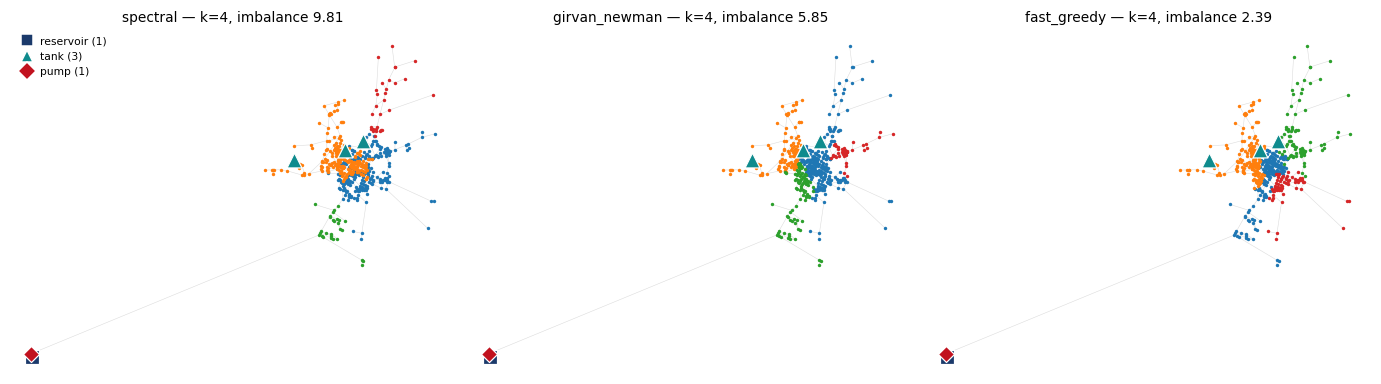

In [6]:
# Static version for export, and every method's own map
fig, axes = plt.subplots(1, len(results), figsize=(4.2 * len(results), 4.4), squeeze=False)
for ax, (name, r) in zip(axes[0], results.items()):
    dst.plots.plot_districts(wn, r.labels, ax,
                             "%s — k=%d, imbalance %.2f"
                             % (name, r.k, r.report["balance"]["count_imbalance"]),
                             status=r.status if r.best else None, node_size=5,
                             legend=(ax is axes[0][0]))
fig.tight_layout(); plt.show()

## 6. Sanity checks

Written by the pipeline (`districting_sanity`), in four blocks: the `districts.yml` **schema
contract**, **partition properties** (contiguity, `k` achieved, no empty district, every node
labelled), **reproducibility** (same config, same labels), and **hydraulics** where Phase 3 ran.

The pipeline raises on the subset a world cannot survive (the simulation's partition contract,
unassigned nodes, `k` not reached); everything else is recorded here. A failing row is not
automatically fatal — the rebalance-tolerance row can legitimately fail when every movable
boundary node is an articulation point of its own district — but it carries the detail needed
to decide.

In [ ]:
SANITY = catalog.load("districting_sanity")
display(SANITY.groupby("method")["ok"].agg(passed="sum", checks="count"))
failures = SANITY[~SANITY["ok"]]
display(failures[["method", "check", "detail"]].reset_index(drop=True)
        if len(failures) else pd.DataFrame({"note": ["every check passed for every method"]}))

In [ ]:
display(SANITY[SANITY["method"] == ("spectral" if "spectral" in results else current[0])])

## 7. Summary

What the partition **is** (districts, sizes, imbalance), what it **costs** (boundary links,
flow meters, gate valves, open length), and how it **scores** (contiguity, modularity,
structural coupling ratio, elevation separation, agreement). Modularity is what the community
methods optimise, so they should win it; `size_imbalance` is not in the paper's objective at
all. A column that needed a Phase-3 run it did not get is `NaN`, never `0`.

Downstream, remember what the placement needs: every district must hold at least
`sensor_placement.slots` distinct live gauges per kind, so a method that cuts a tiny district
(`min_junctions`) may build a partition no world can place sensors on.

In [8]:
SUMMARY = catalog.load("districting_summary")
display(SUMMARY.set_index("method").T)
if REFERENCE:
    print("agreement against the published DMA partition (valid on this network only):")
    display(SUMMARY[["method", "ami_vs_reference", "ari_vs_reference",
                     "size_imbalance", "modularity"]]
            .sort_values("ami_vs_reference", ascending=False).reset_index(drop=True))

[09/16/26 09:27:38] INFO     Loading data from districting_summary (CSVDataset)...             ]8;id=3457;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=803560;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

method,spectral,girvan_newman,fast_greedy,walktrap
network,ky7,ky7,ky7,ky7
partition_id,29fddafe,6f359aad,2ab65bc6,348fcdf6
k_requested,4,4,4,4
n_districts,4,4,4,4
min_junctions,30,40,66,8
max_junctions,215,237,170,426
size_imbalance,9.81,5.85,2.39,82.2
demand_imbalance,6.58,5.88,1.79,32.66
all_contiguous,True,True,True,True
n_fragments_repaired,0,0,0,0


### Is each community partition a unique answer?

A tie-break change (lexical instead of `.inp` vertex order) can send a greedy method to a
different, equally modular optimum. Where `order_sensitive` is True, read that method's row as
*one of several comparably modular answers*. Vertex order is pinned to the network's own.

In [ ]:
display(catalog.load("districting_order_sensitivity"))